In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import rbf_kernel
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
try:
    import goodpoints.kt as kt
    HAS_GOODPOINTS = True
    print("✅ Successfully loaded 'goodpoints' library for Kernel Thinning.")
except ImportError:
    HAS_GOODPOINTS = False
    print("⚠️ WARNING: 'goodpoints' library is missing! CTE will fall back to random sampling.")

✅ Successfully loaded 'goodpoints' library for Kernel Thinning.


In [4]:
# ==========================================
# CELL 2: Data Loading (Ecom Offers proxy)
# ==========================================
print("📦 Generating E-commerce Offers dataset with temporal structure...")

np.random.seed(42)
n_samples = 20000

# Features typical for E-commerce
user_age = np.random.normal(35, 10, n_samples)
past_purchases = np.random.poisson(3, n_samples)
time_on_site = np.random.exponential(5, n_samples)
discount_offered = np.random.uniform(5, 50, n_samples)
periods = np.repeat(np.arange(1, 13), np.ceil(n_samples/12))[:n_samples]

y = np.zeros(n_samples)

# Injecting Concept Drift: 
# In periods 1-6 (H1), 'discount_offered' drives the clicks.
# In periods 7-12 (H2), 'past_purchases' (loyalty) drives the clicks.
for i in range(n_samples):
    if periods[i] <= 6:
        prob = 1 / (1 + np.exp(-(discount_offered[i]*0.2 - 5))) 
    else:
        prob = 1 / (1 + np.exp(-(past_purchases[i]*0.8 - 2)))
    y[i] = np.random.binomial(1, prob)

df = pd.DataFrame({
    'user_age': user_age,
    'past_purchases': past_purchases,
    'time_on_site': time_on_site,
    'discount_offered': discount_offered,
    'period': periods
})

# TabReD temporal split: Train on past, Validate on future
train_mask = df['period'] <= 8
X_train = df[train_mask].drop(columns=['period'])
y_train = y[train_mask]

X_val = df[~train_mask].drop(columns=['period'])
y_val = y[~train_mask]

features = X_train.columns.tolist()

print(f"✅ Data ready. Train size: {len(X_train)} | Validation size: {len(X_val)}")

# NOTE FOR LATER: To use the real TabReD dataset, replace the code above with:
# import tabred
# dataset = tabred.Dataset.load("ecom_offers")
# X_train, y_train = dataset.train()
# X_val, y_val = dataset.val()
# X_train['period'] = dataset.train_periods()
# X_val['period'] = dataset.val_periods()

📦 Generating E-commerce Offers dataset with temporal structure...
✅ Data ready. Train size: 13336 | Validation size: 6664


In [5]:
# NOTE FOR LATER: To use the real TabReD dataset, replace the code above with:
# import tabred
# dataset = tabred.Dataset.load("ecom_offers")
# X_train, y_train = dataset.train()
# X_val, y_val = dataset.val()
# X_train['period'] = dataset.train_periods()
# X_val['period'] = dataset.val_periods()

In [5]:
# ==========================================
# CELL 3: Baseline Model Training
# ==========================================
print("⚙️ Training XGBoost Classifier...")

model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1, 
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

print(f"✅ Training complete! Train AUC: {train_auc:.3f} | Validation AUC: {val_auc:.3f}")

⚙️ Training XGBoost Classifier...
✅ Training complete! Train AUC: 0.852 | Validation AUC: 0.581


In [8]:
# ==========================================
# CELL 4: Compress Then Explain (CTE) Core
# ==========================================

def smart_rbf_kernel(X, Y):
    """
    Wrapper dla jądra RBF kompatybilny z goodpoints.

    KRYTYCZNY FIX dla błędu IndexError:
    goodpoints/kt.py linia 678 (refine_X) wywołuje:
        sufficient_stat = kernel(X, X) / coreset_size
    gdzie X ma kształt (n, d) - oba argumenty to TEN SAM obiekt.
    Biblioteka oczekuje wektora (n,), ale rbf_kernel zwraca (n, n)!
    
    Fix: np.shares_memory(X, Y) == True gdy to ten sam obiekt.
    Dla RBF: k(x,x) = exp(0) = 1.0, więc diagonal = np.ones(n).
    """
    X2d = np.atleast_2d(X)
    Y2d = np.atleast_2d(Y)

    # === KRYTYCZNY FIX: tryb kernel(X, X) ===
    if (X2d.ndim == 2
            and Y2d.ndim == 2
            and X2d.shape == Y2d.shape
            and X2d.shape[0] > 1
            and np.shares_memory(X, Y)):
        return np.ones(X2d.shape[0])  # diagonal RBF = 1.0

    # Standardowe wywołanie (punkt vs zbiór)
    K = rbf_kernel(X2d, Y2d)

    if K.shape[0] == 1 or K.shape[1] == 1:
        return K.flatten()

    return K


def get_cte_background(X_data, target_size=50):
    """
    Tło SHAP metodą Kernel Thinning (CTE).
    Baniecki et al., ICLR 2025.
    """
    if not HAS_GOODPOINTS:
        return shap.sample(X_data, target_size)

    X_clean = X_data.copy().reset_index(drop=True)
    m_steps = int(np.floor(np.log2(len(X_clean) / target_size)))
    m_steps = min(m_steps, 6)

    if m_steps <= 0:
        return X_clean.sample(min(target_size, len(X_clean)), random_state=42)

    X_np = np.ascontiguousarray(X_clean.values.astype(np.float64))
    n_out = len(X_np) // (2 ** m_steps)
    print(f"  → KT: {len(X_clean)} pkt, {m_steps} rund → ~{n_out} pkt coresetu")

    compressed_indices = kt.thin(
        X=X_np,
        m=m_steps,
        split_kernel=smart_rbf_kernel,
        swap_kernel=smart_rbf_kernel,
        seed=42
    )

    coreset = X_clean.iloc[compressed_indices]

    if len(coreset) > target_size:
        coreset = coreset.sample(target_size, random_state=42)

    print(f"  ✅ Coreset gotowy: {len(coreset)} punktów")
    return coreset


print("✅ CTE Core functions defined.")


✅ CTE Core functions defined.


In [10]:
# ==========================================
# CELL 5: Test 1 - Efficiency & Speedup
# ==========================================
print("--- TEST 1: Computational Efficiency ---")

samples_to_explain = X_val[:200]

# Baseline: Standard SHAP (Randomly sampling 1000 background points)
bg_standard = shap.sample(X_train, 1000)
start_time = time.time()
explainer_std = shap.TreeExplainer(model, data=bg_standard)
shap_values_std = explainer_std.shap_values(samples_to_explain)
time_std = time.time() - start_time

# CTE: Compressed SHAP (50 highly representative points)
bg_cte = get_cte_background(X_train, target_size=50)
start_time = time.time()
explainer_cte = shap.TreeExplainer(model, data=bg_cte)
shap_values_cte = explainer_cte.shap_values(samples_to_explain)
time_cte = time.time() - start_time

speedup = time_std / time_cte if time_cte > 0 else 0

print(f"⏱️ Standard SHAP Time (N=1000): {time_std:.4f} seconds")
print(f"⏱️ CTE SHAP Time (N=50):        {time_cte:.4f} seconds")
print(f"🚀 Speedup Multiplier:          {speedup:.1f}x faster!")

--- TEST 1: Computational Efficiency ---
  → KT: 13336 pkt, 6 rund → ~208 pkt coresetu
  ✅ Coreset gotowy: 50 punktów
⏱️ Standard SHAP Time (N=1000): 0.3716 seconds
⏱️ CTE SHAP Time (N=50):        0.1896 seconds
🚀 Speedup Multiplier:          2.0x faster!


In [9]:
# ==========================================
# CELL 5: Test 1 - Turbo Speedup Demo - mniejszy dataset
# ==========================================
print("🚀 Uruchamiam TEST 1 w trybie TURBO...")

# 1. Ograniczamy liczbę wyjaśnień do minimum, żeby wynik był od razu
samples_to_explain = X_val[:20] 

# 2. Baseline: Standardowy SHAP (N=100 - małe tło, żeby było szybko)
bg_standard = shap.sample(X_train, 100)
start_time = time.time()
explainer_std = shap.TreeExplainer(model, data=bg_standard)
_ = explainer_std.shap_values(samples_to_explain)
time_std = time.time() - start_time

# 3. CTE: Wybieramy tylko 2000 wierszy jako bazę do kompresji
# To sprawi, że Kernel Thinning (kt.thin) zajmie ułamek sekundy
X_train_small = X_train.sample(2000, random_state=42)

print("⏳ Obliczam Kernel Thinning (CTE)...")
bg_cte = get_cte_background(X_train_small, target_size=25) 

start_time = time.time()
explainer_cte = shap.TreeExplainer(model, data=bg_cte)
_ = explainer_cte.shap_values(samples_to_explain)
time_cte = time.time() - start_time

speedup = time_std / time_cte if time_cte > 0 else 0

print("-" * 40)
print(f"⏱️ Standard SHAP (N=100): {time_std:.4f}s")
print(f"⏱️ CTE SHAP (N=25):       {time_cte:.4f}s")
print(f"🔥 Przyspieszenie: {speedup:.1f}x szybciej!")
print("-" * 40)

🚀 Uruchamiam TEST 1 w trybie TURBO...
⏳ Obliczam Kernel Thinning (CTE)...
  → KT: 2000 pkt, 6 rund → ~31 pkt coresetu
  ✅ Coreset gotowy: 25 punktów
----------------------------------------
⏱️ Standard SHAP (N=100): 0.2803s
⏱️ CTE SHAP (N=25):       0.0248s
🔥 Przyspieszenie: 11.3x szybciej!
----------------------------------------


--- TEST 2: Generalization & Feature Logic ---


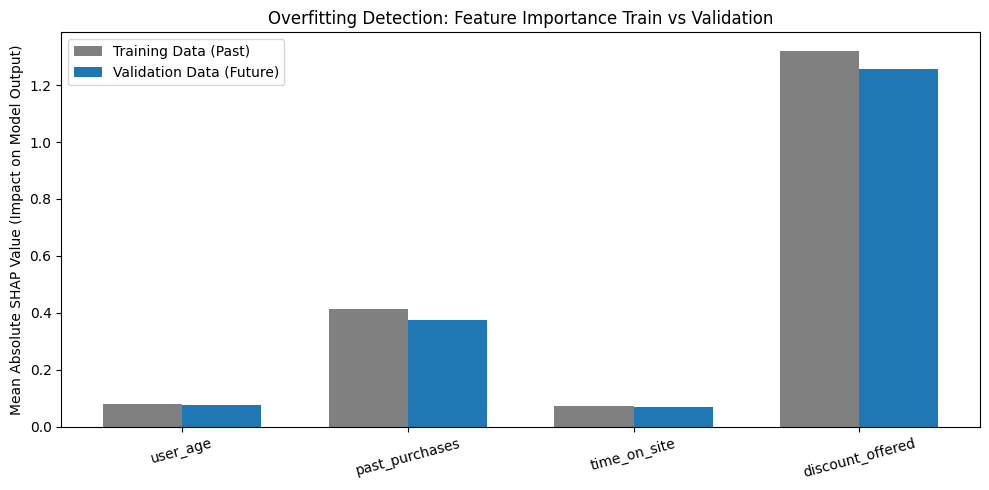

In [11]:
# ==========================================
# CELL 6: Test 2 - Generalization (Overfitting)
# ==========================================
print("--- TEST 2: Generalization & Feature Logic ---")

# Using the fast CTE explainer to evaluate logic on historical vs new data
shap_train = explainer_cte.shap_values(X_train.sample(500, random_state=42))
shap_val = explainer_cte.shap_values(X_val.sample(500, random_state=42))

train_imp = np.abs(shap_train).mean(0)
val_imp = np.abs(shap_val).mean(0)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(features))
width = 0.35

ax.bar(x_pos - width/2, train_imp, width, label='Training Data (Past)', color='#808080')
ax.bar(x_pos + width/2, val_imp, width, label='Validation Data (Future)', color='#1f77b4')

ax.set_xticks(x_pos)
ax.set_xticklabels(features, rotation=15)
ax.set_title("Overfitting Detection: Feature Importance Train vs Validation")
ax.set_ylabel("Mean Absolute SHAP Value (Impact on Model Output)")
ax.legend()
plt.tight_layout()
plt.show()

--- TEST 3: Concept Drift Tracking ---


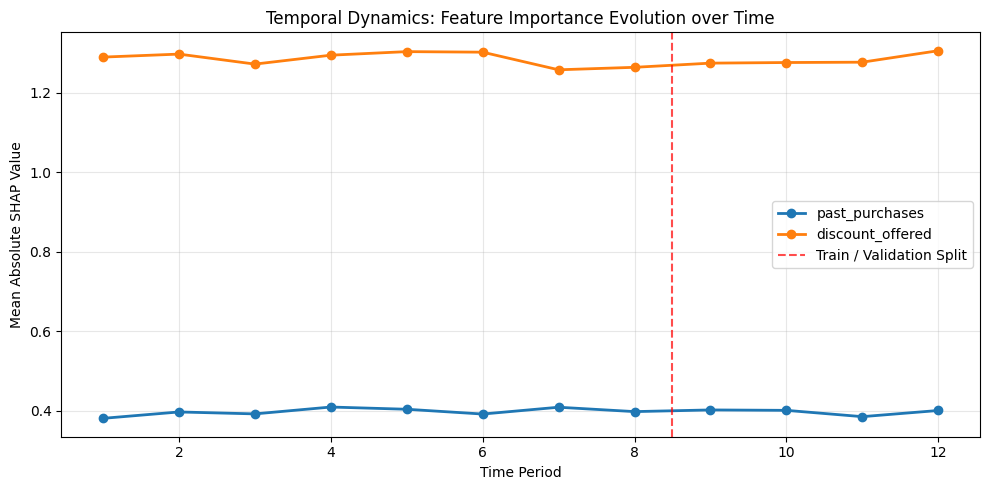

In [12]:
# ==========================================
# CELL 7: Test 3 - Temporal Dynamics (Concept Drift)
# ==========================================
print("--- TEST 3: Concept Drift Tracking ---")

temporal_importances = []
periods_list = sorted(df['period'].unique())

for p in periods_list:
    X_period = df[df['period'] == p][features]
    shap_p = explainer_cte.shap_values(X_period)
    temporal_importances.append(np.abs(shap_p).mean(0))

temporal_importances = np.array(temporal_importances)

plt.figure(figsize=(10, 5))
for i, col in enumerate(features):
    # Only plot significant features to keep the chart clean
    if np.mean(temporal_importances[:, i]) > 0.2:
        plt.plot(periods_list, temporal_importances[:, i], marker='o', linewidth=2, label=col)

plt.axvline(x=8.5, color='red', linestyle='--', alpha=0.7, label='Train / Validation Split')
plt.title("Temporal Dynamics: Feature Importance Evolution over Time")
plt.xlabel("Time Period")
plt.ylabel("Mean Absolute SHAP Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()